# CIFAR-10 Recognition with CNNs

En esta actividad crearás, entrenarás y evaluarás una red neuronal convolucional utilizando PyTorch y el conjunto de datos CIFAR-10.

Para más información sobre el conjunto CIFAR-10, consulta: https://www.cs.toronto.edu/~kriz/cifar.html

In [ ]:
import random

import torch.nn as nn
import torch
import torchvision
from torch.optim import Adam
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

### Load data


In [ ]:
# Convertir imagenes a tensores
to_tensor = transforms.ToTensor()

train_data = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=to_tensor
)

test_data = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=to_tensor
)

In [ ]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

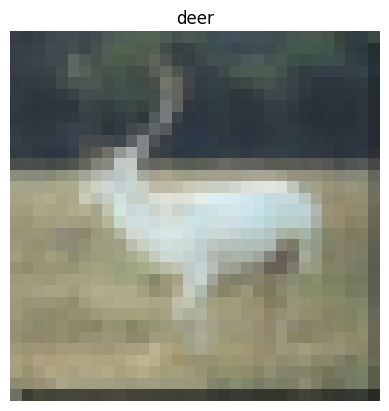

In [ ]:
classes = train_data.classes

def show_cifar(img, lbl):
    img = img.permute(1, 2, 0)  # (C,H,W) → (H,W,C)
    plt.imshow(img)
    plt.title(classes[lbl])
    plt.axis('off')

# Random para visualizacion
idx = random.randrange(len(train_data))
img, lbl = train_data[idx]

show_cifar(img, lbl)

## Training functions

Now we can define our training functions. Since we will use accuracy to evaluate our model, we will create a function to calculate accuracy as well.

In [ ]:
def get_batch_accuracy(output, y):
    pred = output.argmax(dim=1)
    return pred.eq(y).sum().item()

Our train function performs the full training loop. For each epoch, it computes the training loss and accuracy, and then evaluates the model on the validation set. It returns the history of training and validation losses and accuracies for plotting later.

In [147]:
def train(_model, _train_loader, _test_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
    }

    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0

        for X_batch, y_batch in _train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch)

        epoch_train_loss = train_loss / len(_train_loader.dataset)
        epoch_train_acc = train_acc / len(_train_loader.dataset)

        _model.eval()
        test_loss = 0.0
        test_acc = 0.0

        with torch.no_grad():
            for X_test, y_test in _test_loader:
                X_test = X_test.to(device)
                y_test = y_test.to(device)

                outputs = _model(X_test)
                test_loss += _criterion(outputs, y_test).item() * X_test.size(0)
                test_acc += get_batch_accuracy(outputs, y_test)

        epoch_test_loss = test_loss / len(_test_loader.dataset)
        epoch_test_acc = test_acc / len(_test_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{epoch_train_acc:.4f}",
            test_loss=f"{epoch_test_loss:.4f}",
            test_acc=f"{epoch_test_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(epoch_train_acc)
        res['test_loss'].append(epoch_test_loss)
        res['test_acc'].append(epoch_test_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [169]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0

    with torch.no_grad():
        for x, y in _test_loader:
            x = x.to(device)
            y = y.to(device)

            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y)

    epoch_test_loss = test_loss / len(_test_loader.dataset)
    epoch_test_acc = test_acc / len(_test_loader.dataset)

    return epoch_test_loss, epoch_test_acc

## Training the models

### CNN model

Now let's implement a simple CNN architecture. We will use three convolutional layers followed by max pooling, and then a couple of fully connected layers before the output layer.

In [148]:
def plot_learning_curves(res, title):
    epochs = range(1, len(res['train_loss']) + 1)

    plt.figure(figsize=(10,5))
    plt.plot(epochs, res['train_loss'], label="Train Loss")
    plt.plot(epochs, res['test_loss'], label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.show()

In [149]:
# MODELO 1
model_cnn = nn.Sequential(
    nn.Conv2d(3, 25, 3, stride=1, padding=1),  # 25 x 32 x 32
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                # 25 x 16 x 16

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  # 50 x 16 x 16
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),                 # 50 x 8 x 8

    nn.Conv2d(50, 75, 3, stride=1, padding=1),  # 75 x 8 x 8
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                 # 75 x 4 x 4

    nn.Flatten(),
    nn.Linear(75 * 4 * 4, 512),               # 1200 → 512
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 10)                        #  10 clases
)

model_cnn = model_cnn.to(device)

# Iguales para todos los modelos
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(
    model_cnn,
    train_loader,
    test_loader,
    loss_function,
    optimizer,
    epochs)

Training: 100%|██████████| 20/20 [04:53<00:00, 14.69s/epoch, test_acc=0.7396, test_loss=0.9268, train_acc=0.8763, train_loss=0.3429]


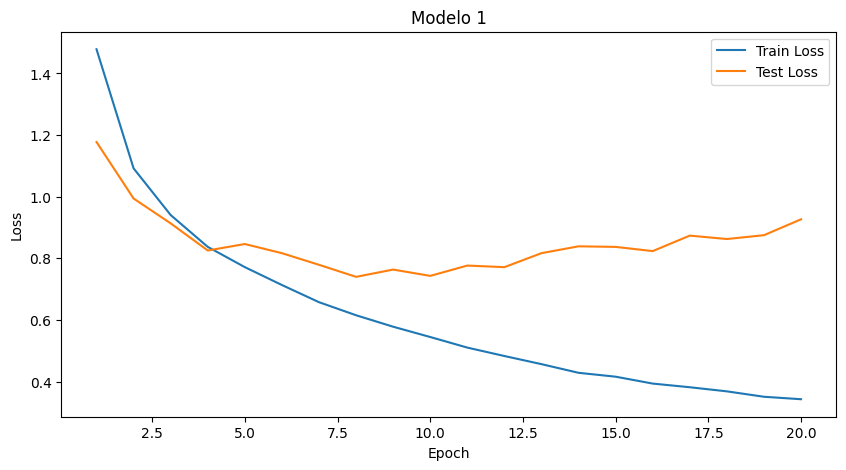

In [150]:
plot_learning_curves(cnn_res, "Modelo 1")

In [151]:
# MODELO 2
model_cnn_2 = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1),      # 32 x 32 x 32
    nn.ReLU(),
    nn.MaxPool2d(2),                     # 32 x 16 x 16

    nn.Conv2d(32, 64, 3, padding=1),     # 64 x 16 x 16
    nn.ReLU(),
    nn.MaxPool2d(2),                     # 64 x 8 x 8

    nn.Conv2d(64, 128, 3, padding=1),    # 128 x 8 x 8
    nn.ReLU(),
    nn.MaxPool2d(2),                     # 128 x 4 x 4

    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)

model_cnn_2 = model_cnn_2.to(device)

optimizer2 = Adam(model_cnn_2.parameters())

cnn_res_2 = train(
    model_cnn_2,
    train_loader,
    test_loader,
    loss_function,
    optimizer2,
    epochs
)

Training: 100%|██████████| 20/20 [04:37<00:00, 13.89s/epoch, test_acc=0.7152, test_loss=1.8596, train_acc=0.9603, train_loss=0.1121]


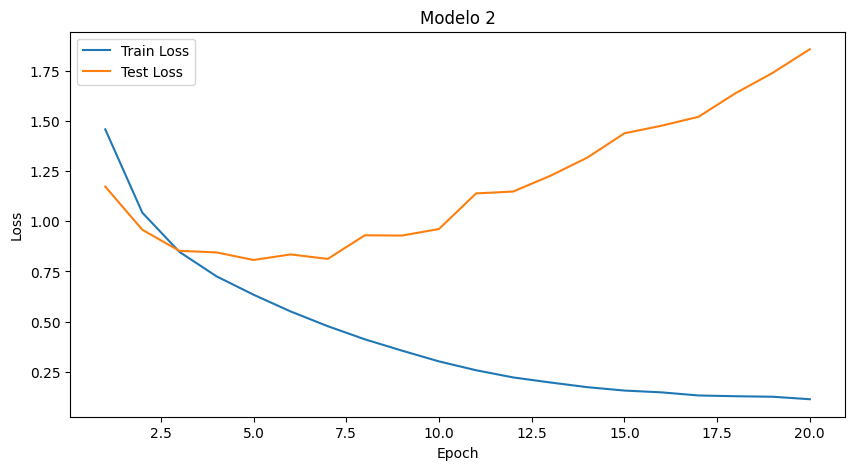

In [152]:
plot_learning_curves(cnn_res_2, "Modelo 2")

In [153]:
model_cnn_3 = nn.Sequential(
    nn.Conv2d(3, 16, 3, padding=1),      # 16 x 32 x 32
    nn.ReLU(),
    nn.MaxPool2d(2),                     # 16 x 16 x 16

    nn.Conv2d(16, 32, 3, padding=1),     # 32 x 16 x 16
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2),                     # 32 x 8 x 8

    nn.Conv2d(32, 64, 3, padding=1),     # 64 x 8 x 8
    nn.ReLU(),
    nn.Dropout(.3),
    nn.MaxPool2d(2),                     # 64 x 4 x 4

    nn.Flatten(),
    nn.Linear(64 * 4 * 4, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

model_cnn_3 = model_cnn_3.to(device)

optimizer3 = Adam(model_cnn_3.parameters())

res_model_3 = train(
    model_cnn_3,
    train_loader,
    test_loader,
    loss_function,
    optimizer3,
    epochs
)

Training: 100%|██████████| 20/20 [04:28<00:00, 13.41s/epoch, test_acc=0.7300, test_loss=0.7756, train_acc=0.8058, train_loss=0.5388]


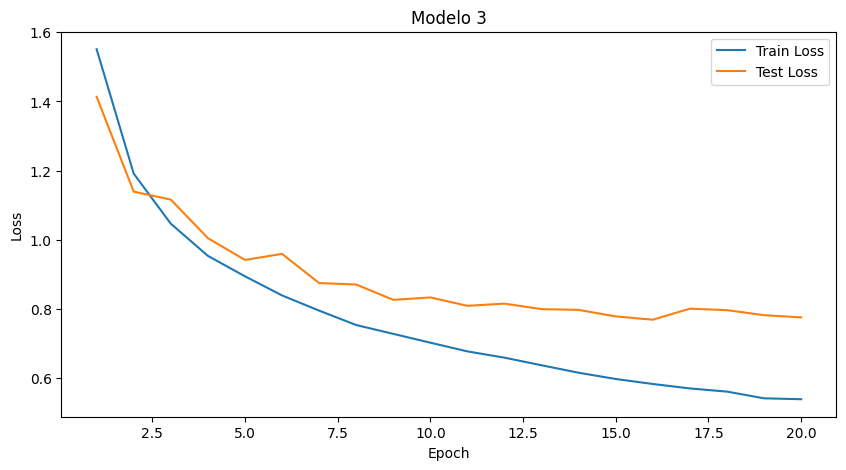

In [155]:
plot_learning_curves(res_model_3, "Modelo 3")

## Evaluation

In [170]:
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

print(f"Model 1 - Test Loss: {cnn_test_loss:.4f}")
print(f"Model 1 - Test Accuracy: {cnn_test_acc:.4f}")

Model 1 - Test Loss: 0.9268
Model 1 - Test Accuracy: 0.7396


In [171]:
cnn_test_loss_2, cnn_test_acc_2 = test(model_cnn_2, test_loader, loss_function)

print(f"Model 2 - Test Loss: {cnn_test_loss_2:.4f}")
print(f"Model 2 - Test Accuracy: {cnn_test_acc:.4f}")

Model 2 - Test Loss: 1.8596
Model 2 - Test Accuracy: 0.7396


In [172]:
cnn_test_loss_3, cnn_test_acc_3 = test(model_cnn_3, test_loader, loss_function)

print(f"Model 3 - Test Loss: {cnn_test_loss_3:.4f}")
print(f"Model 3 - Test Accuracy: {cnn_test_acc_3:.4f}")

Model 3 - Test Loss: 0.7756
Model 3 - Test Accuracy: 0.7300


In [174]:
# Comparacion
max_acc = max(cnn_test_acc, cnn_test_acc_2, cnn_test_acc_3)

if max_acc == cnn_test_acc:
    best_model = model_cnn
    best_res = cnn_res
    print("Modelo 1 es el mejor")

elif max_acc == cnn_test_acc_2:
    best_model = model_cnn_2
    best_res = cnn_res_2
    print("Modelo 2 es el mejor")

else:
    best_model = model_cnn_3
    best_res = res_model_3
    print("Modelo 3 es el mejor")

print("Mejor accuracy:", max_acc)

Modelo 1 es el mejor
Mejor accuracy: 0.7396


##Extra

In [188]:
from PIL import Image
import torchvision.transforms as transforms

def predict_image(path, model, classes):
    model.eval()

    # Conversion a Tensores
    transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor()
    ])

    # 3 Canales RGB
    img = Image.open(path).convert("RGB")
    img = transform(img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        output = model(img)
        pred = output.argmax(dim=1).item()

    return classes[pred]

label = predict_image("extra.jpg", best_model, classes)
print("Prediccion:", label)

Prediccion: horse


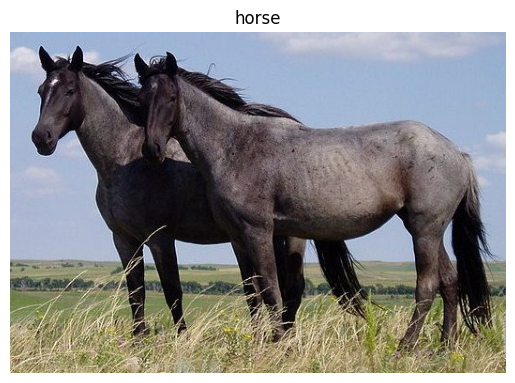

In [186]:
def show_prediction(path, model, classes):
    img = Image.open(path).convert("RGB")
    label = predict_image(path, model, classes)

    plt.imshow(img)
    plt.title(label)
    plt.axis('off')
    plt.show()

show_prediction("extra.jpg", best_model, classes)

## Reflection section

### Which model is better at classifying ASL images?

### Final conclusions and remarks